In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import joblib
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Admin\Desktop\PROJECT FILE\cybersecurity_intrusion_data.csv")

df.head()

C:\Users\Admin\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\Admin\anaconda3\lib\site-packages\numpy\.libs\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll
C:\Users\Admin\anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [3]:
X = df.drop("login_attempts", axis=1)
y = df["login_attempts"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (7629, 10)
Testing Shape: (1908, 10)


In [16]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier


# LOAD DATASET
df = pd.read_csv(
    r"C:\Users\Admin\Desktop\PROJECT FILE\cybersecurity_intrusion_data.csv"
)

# CLEAN DATASET
df_clean = df.copy()

label_encoders = {}

for col in df_clean.columns:
    if df_clean[col].dtype == "object":
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        label_encoders[col] = le

print("Cleaned Dataset Shape:", df_clean.shape)


# FEATURES AND TARGET
target_column = "attack_detected"

X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]


# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


# MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric="logloss"
    )
}

results = []
trained_models = {}
confusion_matrices = {}


# TRAIN & EVALUATE MODELS
for name, model in models.items():

    print(f"\n{'='*50}")
    print(f"Training {name}")
    print(f"{'='*50}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # METRICS
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    # ROC-AUC (SAFE HANDLING)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    trained_models[name] = model
    confusion_matrices[name] = cm

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")


# RESULTS TABLE
results_df = pd.DataFrame(results)

print("\nMODEL COMPARISON")

results_df_sorted = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

display(results_df_sorted)


# BEST MODEL (BASED ON ROC-AUC)
best_model_name = results_df.loc[
    results_df["ROC-AUC"].idxmax(),
    "Model"
]

best_model = trained_models[best_model_name]

print(f"\nBest Model: {best_model_name}")


# SAVE ONLY BEST MODEL
joblib.dump(best_model, "best_model.pkl")

# SAVE RESULTS TABLE ONLY
results_df.to_csv("model_results.csv", index=False)

print("\nSaved Files:")
print("- best_model.pkl")
print("- model_results.csv")

Cleaned Dataset Shape: (9537, 11)
Training Shape: (7629, 10)
Testing Shape: (1908, 10)

Training Logistic Regression
Accuracy  : 0.7154
Precision : 0.7144
Recall    : 0.7154
F1 Score  : 0.7136
ROC-AUC   : 0.7682

Training Decision Tree
Accuracy  : 0.8108
Precision : 0.8110
Recall    : 0.8108
F1 Score  : 0.8109
ROC-AUC   : 0.8090

Training Random Forest
Accuracy  : 0.8852
Precision : 0.9041
Recall    : 0.8852
F1 Score  : 0.8823
ROC-AUC   : 0.8778

Training SVM
Accuracy  : 0.5556
Precision : 0.5665
Recall    : 0.5556
F1 Score  : 0.4112
ROC-AUC   : 0.5129

Training Naive Bayes
Accuracy  : 0.8113
Precision : 0.8159
Recall    : 0.8113
F1 Score  : 0.8086
ROC-AUC   : 0.8435

Training XGBoost
Accuracy  : 0.8805
Precision : 0.8947
Recall    : 0.8805
F1 Score  : 0.8779
ROC-AUC   : 0.8738

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.885220,0.904121,0.885220,0.882252,0.877778
5,XGBoost,0.880503,0.894709,0.880503,0.877909,0.873790
4,Naive Bayes,0.811321,0.815859,0.811321,0.808597,0.843545
1,Decision Tree,0.810797,0.810962,0.810797,0.810868,0.809045
0,Logistic Regression,0.715409,0.714366,0.715409,0.713577,0.768188
3,SVM,0.555556,0.566543,0.555556,0.411220,0.512883



Best Model: Random Forest

Saved Files:
- best_model.pkl
- model_results.csv


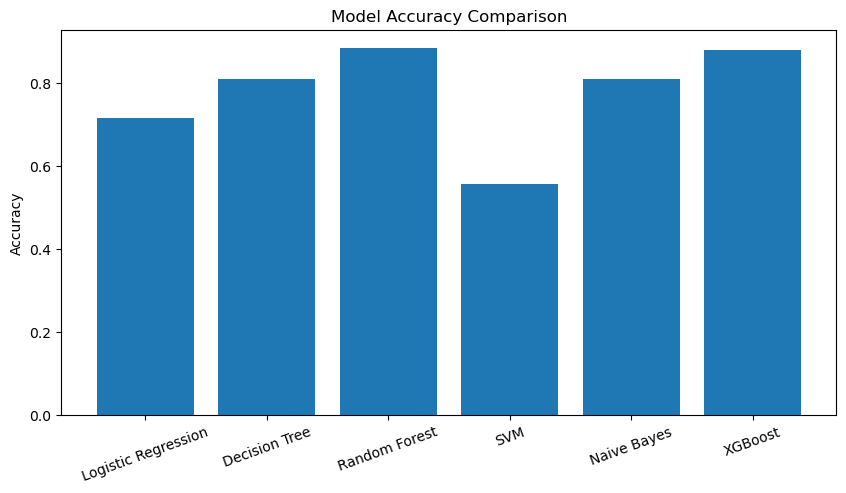

In [17]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)

plt.show()

In [19]:
rf_params = {

    "n_estimators": [100, 200],

    "max_depth": [5, 10, 20],

    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Score:")
print(rf_grid.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}

Best Score:
0.8967087639387235


In [21]:
xgb_params = {

    "n_estimators": [100, 200],

    "max_depth": [3, 5, 7],

    "learning_rate": [0.01, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False
    ),
    xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_grid.best_params_)

print("Best Score:")
print(xgb_grid.best_score_)

Best Parameters:
{'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}
Best Score:
0.8957913327460627


In [22]:
best_model_name = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).iloc[0]["Model"]

best_model = trained_models[best_model_name]

joblib.dump(
    best_model,
    "best_model.pkl"
)

print(f"{best_model_name} saved successfully!")

Random Forest saved successfully!


In [23]:
loaded_model = joblib.load(
    "best_model.pkl"
)

sample_prediction = loaded_model.predict(
    X_test.iloc[:5]
)

print(sample_prediction)

[1 1 1 0 0]
